Analysis Pipeline

In [ ]:

import pandas as pd

sleep_df = pd.read_excel(
    "cleaned_output/Fitbit_su_cleaned/Fitbit_su_sleep_score_cleaned.xlsx"
)

sleep_df["timestamp"] = pd.to_datetime(sleep_df["timestamp"], errors="coerce")
sleep_df["date"] = sleep_df["timestamp"].dt.date

sleep_daily = (
    sleep_df
    .groupby("date")[["overall_score", "deep_sleep_in_minutes", "restlessness"]]
    .mean()
    .reset_index()
)

sleep_daily.describe()


,overall_score,deep_sleep_in_minutes,restlessness
count,17.000000,17.000000,17.000000
mean,71.000000,54.235294,0.133583
std,3.952847,21.784540,0.027203
min,64.000000,24.000000,0.084605
25%,68.000000,38.000000,0.121481
50%,71.000000,52.000000,0.135550
75%,73.000000,68.000000,0.147914
max,78.000000,102.000000,0.195244


In [ ]:
# Stress Data Processing
stress_df = pd.read_excel(
    "cleaned_output/Fitbit_su_cleaned/Fitbit_su_stress_score_cleaned.xlsx"
)

stress_df["date"] = pd.to_datetime(stress_df["date"], errors="coerce").dt.date

stress_daily = (
    stress_df
    .groupby("date")["stress_score"]
    .mean()
    .reset_index()
)

stress_daily.describe()


,stress_score
count,18.000000
mean,54.611111
std,35.157024
min,0.000000
25%,16.250000
50%,72.500000
75%,79.000000
max,83.000000


In [ ]:
# Correlation Analysis between Sleep and Stress
sleep_stress = pd.merge(
    sleep_daily,
    stress_daily,
    on="date",
    how="inner"
)
sleep_stress_numeric = sleep_stress.select_dtypes(include="number")
sleep_stress_numeric.corr()


,overall_score,deep_sleep_in_minutes,restlessness,stress_score
overall_score,1.000000,0.133549,-0.277147,0.212048
deep_sleep_in_minutes,0.133549,1.000000,0.031009,0.504979
restlessness,-0.277147,0.031009,1.000000,-0.455257
stress_score,0.212048,0.504979,-0.455257,1.000000


In [ ]:
# Activity Data Processing
activity_df = pd.read_excel(
    "cleaned_output/Fitbit_su_cleaned/Fitbit_su_active_zone_minutes_(azm)_cleaned.xlsx"
)

activity_df["date"] = pd.to_datetime(activity_df["date_time"], errors="coerce").dt.date

activity_daily = (
    activity_df
    .groupby("date")["total_minutes"]
    .sum()
    .reset_index(name="active_minutes")
)

activity_daily.describe()


,active_minutes
count,27.000000
mean,25.037037
std,35.774380
min,1.000000
25%,7.500000
50%,13.000000
75%,35.000000
max,184.000000


In [ ]:
# Correlation Analysis between Activity and Stress
activity_stress = pd.merge(
    activity_daily,
    stress_daily,
    on="date",
    how="inner"
)

activity_stress_numeric = activity_stress.select_dtypes(include="number")
activity_stress_numeric.corr()

,active_minutes,stress_score
active_minutes,1.00000,0.21735
stress_score,0.21735,1.00000


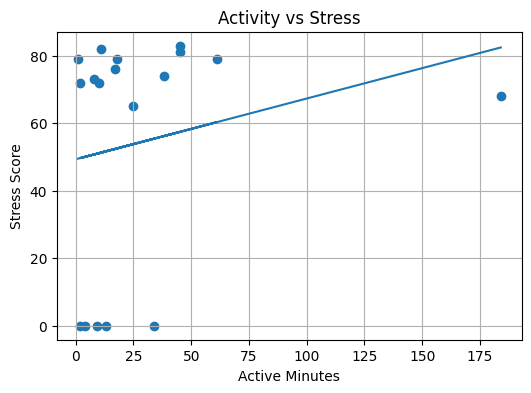

In [43]:
import matplotlib.pyplot as plt
import numpy as np

x = activity_stress["active_minutes"]
y = activity_stress["stress_score"]

plt.figure(figsize=(6, 4))
plt.scatter(x, y)

# Trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Active Minutes")
plt.ylabel("Stress Score")
plt.title("Activity vs Stress")
plt.grid(True)
plt.show()


In [ ]:
# HRV Data Processing
import pandas as pd

hrv_df = pd.read_excel(
    "cleaned_output/Fitbit_su_cleaned/Fitbit_su_heart_rate_variability_cleaned.xlsx"
)

# Ensure datetime
hrv_df["timestamp"] = pd.to_datetime(hrv_df["timestamp"], errors="coerce")
hrv_df["date"] = hrv_df["timestamp"].dt.date

# Daily HRV summary
hrv_daily = (
    hrv_df
    .groupby("date")[["rmssd", "nremhr", "entropy", "daily_respiratory_rate"]]
    .mean()
    .reset_index()
)

hrv_daily.describe()


,rmssd,nremhr,entropy,daily_respiratory_rate
count,19.000000,19.000000,19.000000,19.000000
mean,24.460023,0.814350,0.026326,0.178225
std,9.434690,0.375427,0.012094,0.082494
min,0.000000,0.000000,0.000000,0.000000
25%,20.832214,0.837858,0.028365,0.183516
50%,24.014888,0.942792,0.029826,0.202326
75%,27.648732,1.014410,0.032742,0.224472
max,47.302529,1.155215,0.037236,0.262295


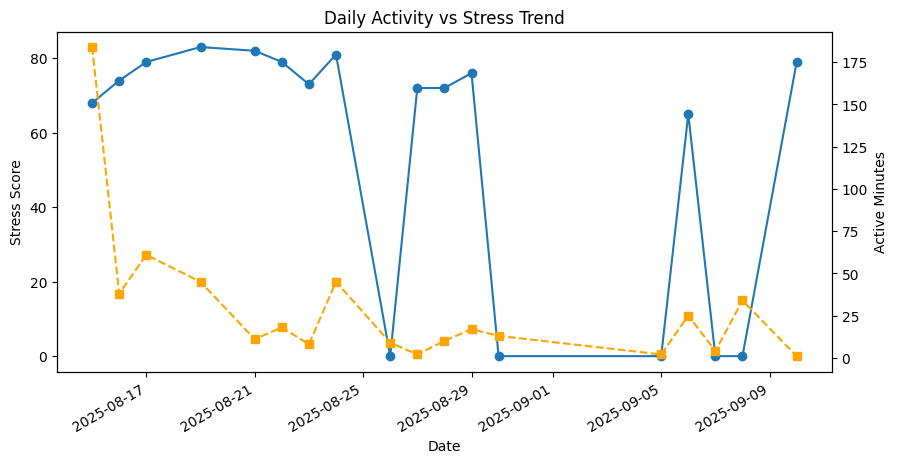

In [44]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Stress (left axis)
ax1.plot(
    activity_stress["date"],
    activity_stress["stress_score"],
    marker="o",
    label="Stress Score"
)
ax1.set_ylabel("Stress Score")
ax1.set_xlabel("Date")

# Activity (right axis)
ax2 = ax1.twinx()
ax2.plot(
    activity_stress["date"],
    activity_stress["active_minutes"],
    marker="s",
    linestyle="--",
    color="orange",
    label="Active Minutes"
)
ax2.set_ylabel("Active Minutes")

plt.title("Daily Activity vs Stress Trend")
fig.autofmt_xdate()
plt.show()


In [ ]:
# Sleep Data Processing
sleep_df = pd.read_excel(
    "cleaned_output/Fitbit_su_cleaned/Fitbit_su_sleep_score_cleaned.xlsx"
)

sleep_df["timestamp"] = pd.to_datetime(sleep_df["timestamp"], errors="coerce")
sleep_df["date"] = sleep_df["timestamp"].dt.date

sleep_daily = (
    sleep_df
    .groupby("date")[[
        "overall_score",
        "deep_sleep_in_minutes",
        "restlessness"
    ]]
    .mean()
    .reset_index()
)

sleep_daily.describe()


,overall_score,deep_sleep_in_minutes,restlessness
count,17.000000,17.000000,17.000000
mean,71.000000,54.235294,0.133583
std,3.952847,21.784540,0.027203
min,64.000000,24.000000,0.084605
25%,68.000000,38.000000,0.121481
50%,71.000000,52.000000,0.135550
75%,73.000000,68.000000,0.147914
max,78.000000,102.000000,0.195244


In [ ]:
# Correlation Analysis between Sleep and HRV
sleep_hrv = pd.merge(
    sleep_daily,
    hrv_daily,
    on="date",
    how="inner"
)

sleep_hrv.head()


,date,overall_score,deep_sleep_in_minutes,restlessness,rmssd,nremhr,entropy,daily_respiratory_rate
0,2025-08-15,67.0,37.0,0.135550,37.349110,1.009604,0.029000,0.184615
1,2025-08-16,73.0,43.0,0.084605,21.073928,1.053536,0.029826,0.226087
2,2025-08-17,73.0,52.0,0.126255,22.982415,1.155215,0.036646,0.258462
3,2025-08-19,78.0,62.0,0.147952,24.014888,0.895738,0.031825,0.195000
4,2025-08-21,77.0,68.0,0.096022,22.926240,1.015040,0.029960,0.210667


In [ ]:
# Correlation matrix
sleep_hrv[
    ["rmssd", "overall_score", "deep_sleep_in_minutes", "restlessness"]
].corr()


,rmssd,overall_score,deep_sleep_in_minutes,restlessness
rmssd,1.000000,-0.276379,-0.308202,0.485622
overall_score,-0.276379,1.000000,0.133549,-0.277147
deep_sleep_in_minutes,-0.308202,0.133549,1.000000,0.031009
restlessness,0.485622,-0.277147,0.031009,1.000000


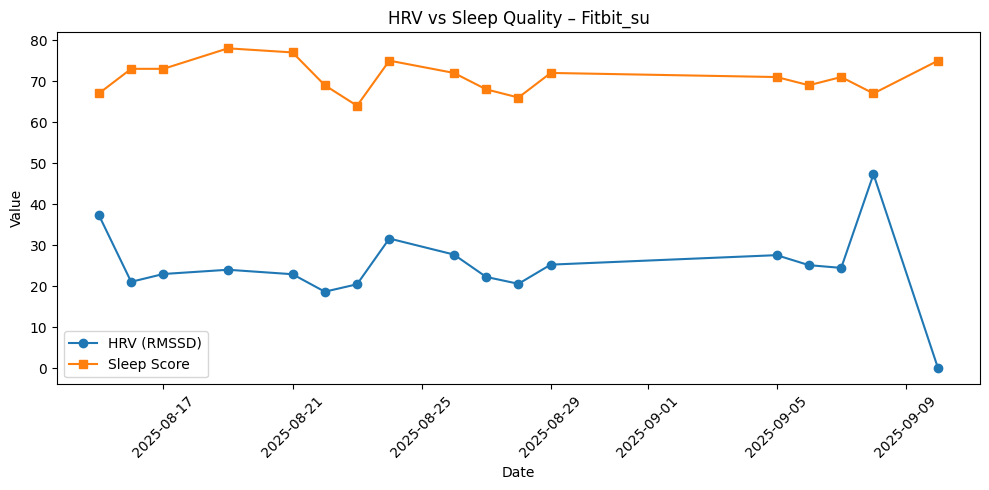

In [ ]:
# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(sleep_hrv["date"], sleep_hrv["rmssd"], marker="o", label="HRV (RMSSD)")
plt.plot(sleep_hrv["date"], sleep_hrv["overall_score"], marker="s", label="Sleep Score")

plt.title("HRV vs Sleep Quality – Fitbit_su")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Correlation Analysis between HRV and Stress
stress_df = pd.read_excel(
    "cleaned_output/Fitbit_su_cleaned/Fitbit_su_stress_score_cleaned.xlsx"
)

stress_df["date"] = pd.to_datetime(stress_df["date"], errors="coerce").dt.date

stress_daily = (
    stress_df
    .groupby("date")["stress_score"]
    .mean()
    .reset_index()
)

stress_hrv = pd.merge(hrv_daily, stress_daily, on="date", how="inner")

stress_hrv[["rmssd", "stress_score"]].corr()


,rmssd,stress_score
rmssd,1.000000,-0.452011
stress_score,-0.452011,1.000000


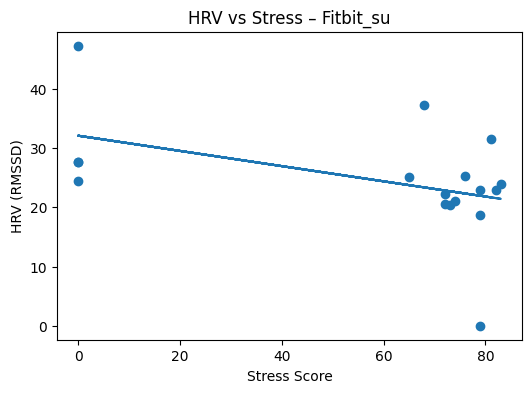

In [ ]:
# Visualization
import matplotlib.pyplot as plt
import numpy as np

x = stress_hrv["stress_score"]
y = stress_hrv["rmssd"]

plt.figure(figsize=(6, 4))
plt.scatter(x, y)

# Trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Stress Score")
plt.ylabel("HRV (RMSSD)")
plt.title("HRV vs Stress – Fitbit_su")
plt.show()


Temp Data is not recommended to use is very unstable